In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
df4= pd.read_csv("4khz.csv")
df1 = pd.read_csv("1khz.csv")



FileNotFoundError: ignored

In [9]:
list(df4)

NameError: ignored

In [ ]:
list(df1)

['Frequency (Hz) - y0 (u0)',
 'Magnitude (abs) - y0 (u0)',
 'Phase (deg) - y0 (u0)']

In [ ]:
freq_4 = np.array(df4['Frequency (Hz) - y0 (u0)'])
mag_4 = np.array(df4['Magnitude (abs) - y0 (u0)'])
phase_4 = np.array(df4['Phase (deg) - y0 (u0)'])

freq_1 = np.array(df1['Frequency (Hz) - y0 (u0)'])
mag_1 = np.array(df1['Magnitude (abs) - y0 (u0)'])
phase_1 = np.array(df1['Phase (deg) - y0 (u0)'])



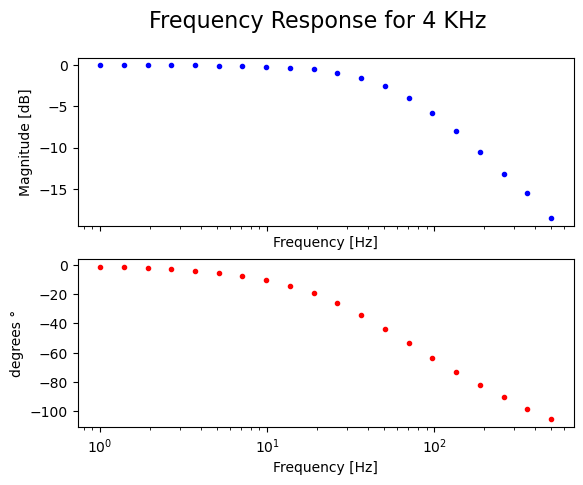

In [ ]:
#4KHZ

fig4, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
fig4.suptitle('Frequency Response for 4 KHz', fontsize=16)
   

ax1.semilogx(freq_4,20*np.log10(mag_4),'.b')
ax2.semilogx(freq_4,phase_4,'.r')


ax1.set_xlabel('Frequency [Hz]')
ax1.set_ylabel('Magnitude [dB]')

ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel('degrees °')


plt.show()


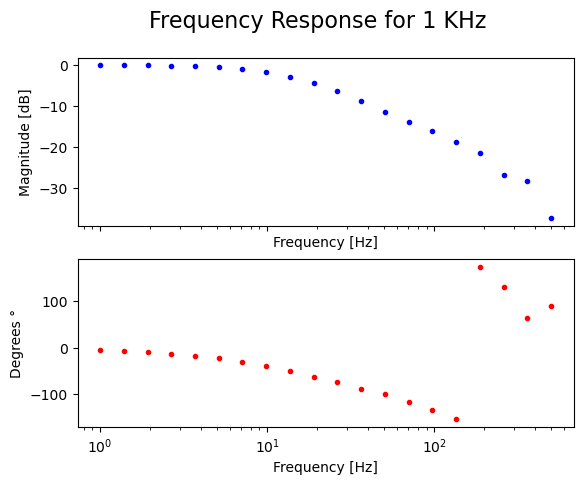

In [ ]:
# 1 KHz

fig1, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
fig1.suptitle('Frequency Response for 1 KHz', fontsize=16)
   

ax1.semilogx(freq_1,20*np.log10(mag_1),'.b')
ax2.semilogx(freq_1,phase_1,'.r')


ax1.set_xlabel('Frequency [Hz]')
ax1.set_ylabel('Magnitude [dB]')

ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel('Degrees °')


plt.show()


In [ ]:
# step response

df_step = pd.read_csv("step_rc.csv")




In [ ]:
time = np.array(df_step['Time - Plot 1'])
amp = np.array(df_step['Amplitude - Plot 1'])
square_input = np.array(df_step['Amplitude - Plot 0'])

In [ ]:
tau_line_x = np.arange(min(time), max(time)+0.001, 0.001)
tau_line_y = np.ones(tau_line_x.size) * (1-math.exp(-1))

In [ ]:
tau_line_y

array([0.63212056, 0.63212056, 0.63212056, ..., 0.63212056, 0.63212056,
       0.63212056])

In [ ]:
print(tau_line_y.size)
print(amp.size)

1440
1440


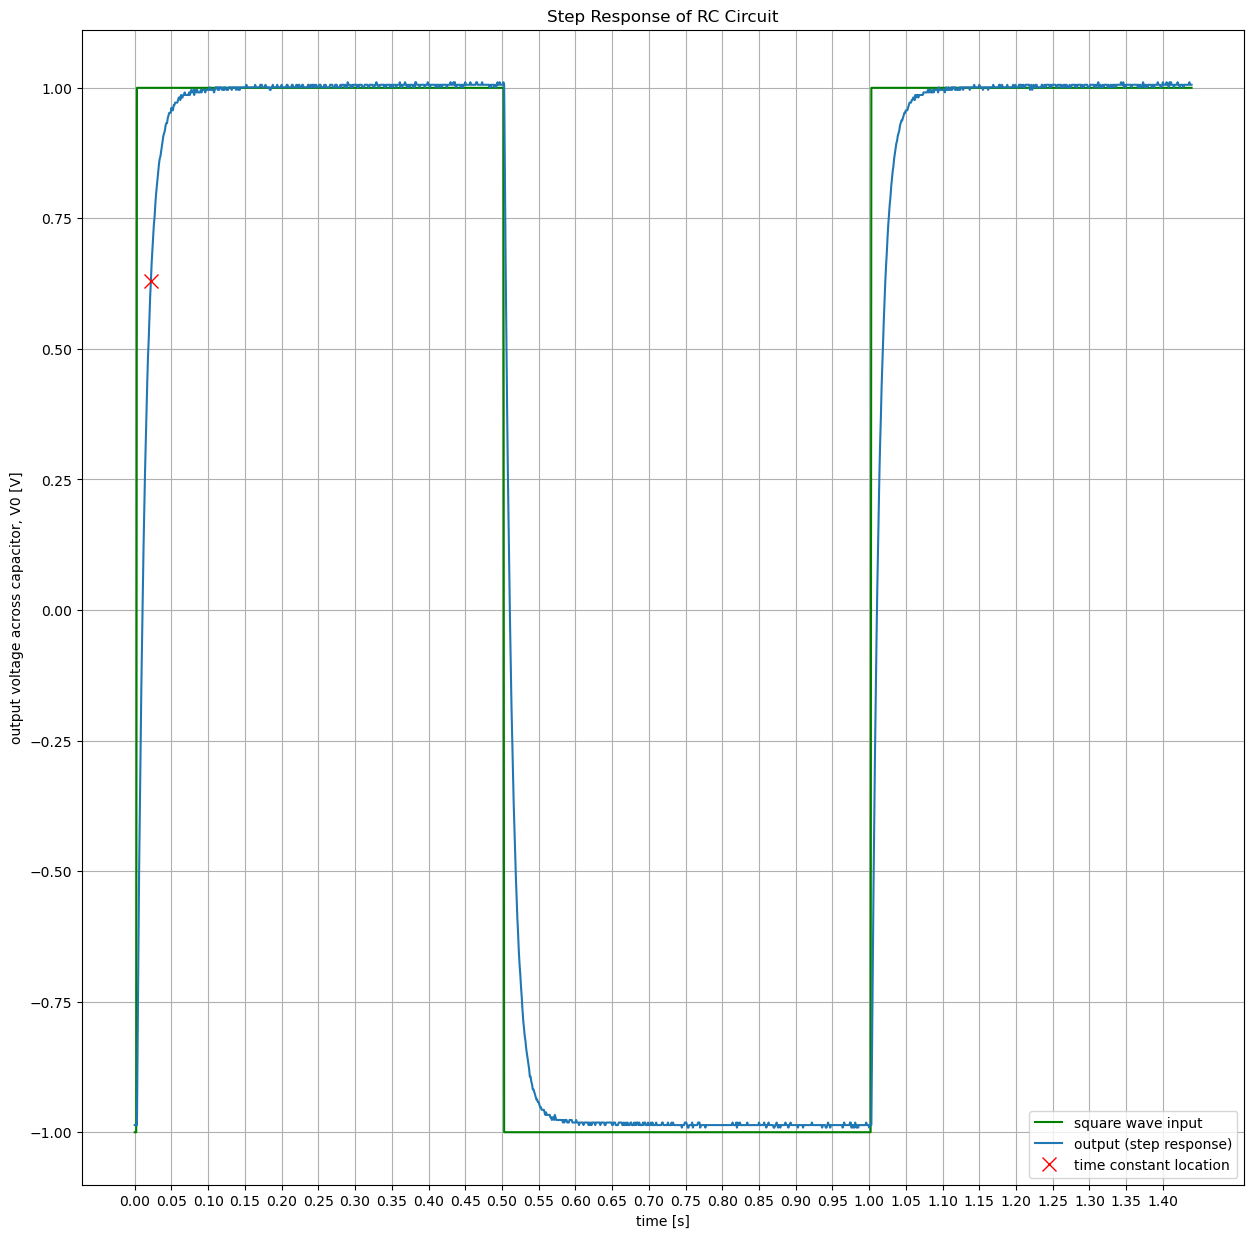

In [ ]:
fig_step = plt.figure(figsize = (15,15))
plt.xlabel('time [s]')
plt.ylabel('output voltage across capacitor, V0 [V]')
plt.title('Step Response of RC Circuit')
plt.xticks(np.arange(min(time), max(time)+0.01, 0.05))

plt.plot(time,square_input,'g-', label = 'square wave input')
plt.plot(time,amp, label = 'output (step response)')

idx = np.argwhere(np.diff(np.sign(amp - tau_line_y))).flatten()
plt.grid()
plt.plot(time[idx[0]], amp[idx[0]], 'rx', markersize = '10', label = 'time constant location')
plt.legend(loc = 'lower right')
plt.show()


# excuse the inaccuracy of the plot. The first dot looks okay and is the easiest estimate of the time constant








In [ ]:
tau_idx = idx[0]
print('idx of tau_measured:',tau_idx)

tau_measured = time[tau_idx]
print('measured time constant:', tau_measured)

idx of tau_measured: 22
measured time constant: 0.022


In [ ]:
# truncate rest of data
amp_2 = amp[0:tau_idx+1]

zero_time_val =  time[np.absolute(amp_2).argmin()]
print(zero_time_val)
tau_measured_corrected = tau_measured - zero_time_val

0.011


In [ ]:
df4= pd.read_csv("manitude_double_intergrator_plant.csv")
df1 = pd.read_csv("phase_double_intergrator_plant.csv")